# Import libraries, functions, classes and paths

In [2]:
import os
from config.paths import *
from lidar.helper_functions import display_las_extent
from lidar.las import LAS
from utils.helper_functions import list_files
from config.paths import use

# Preprocessing

## get info

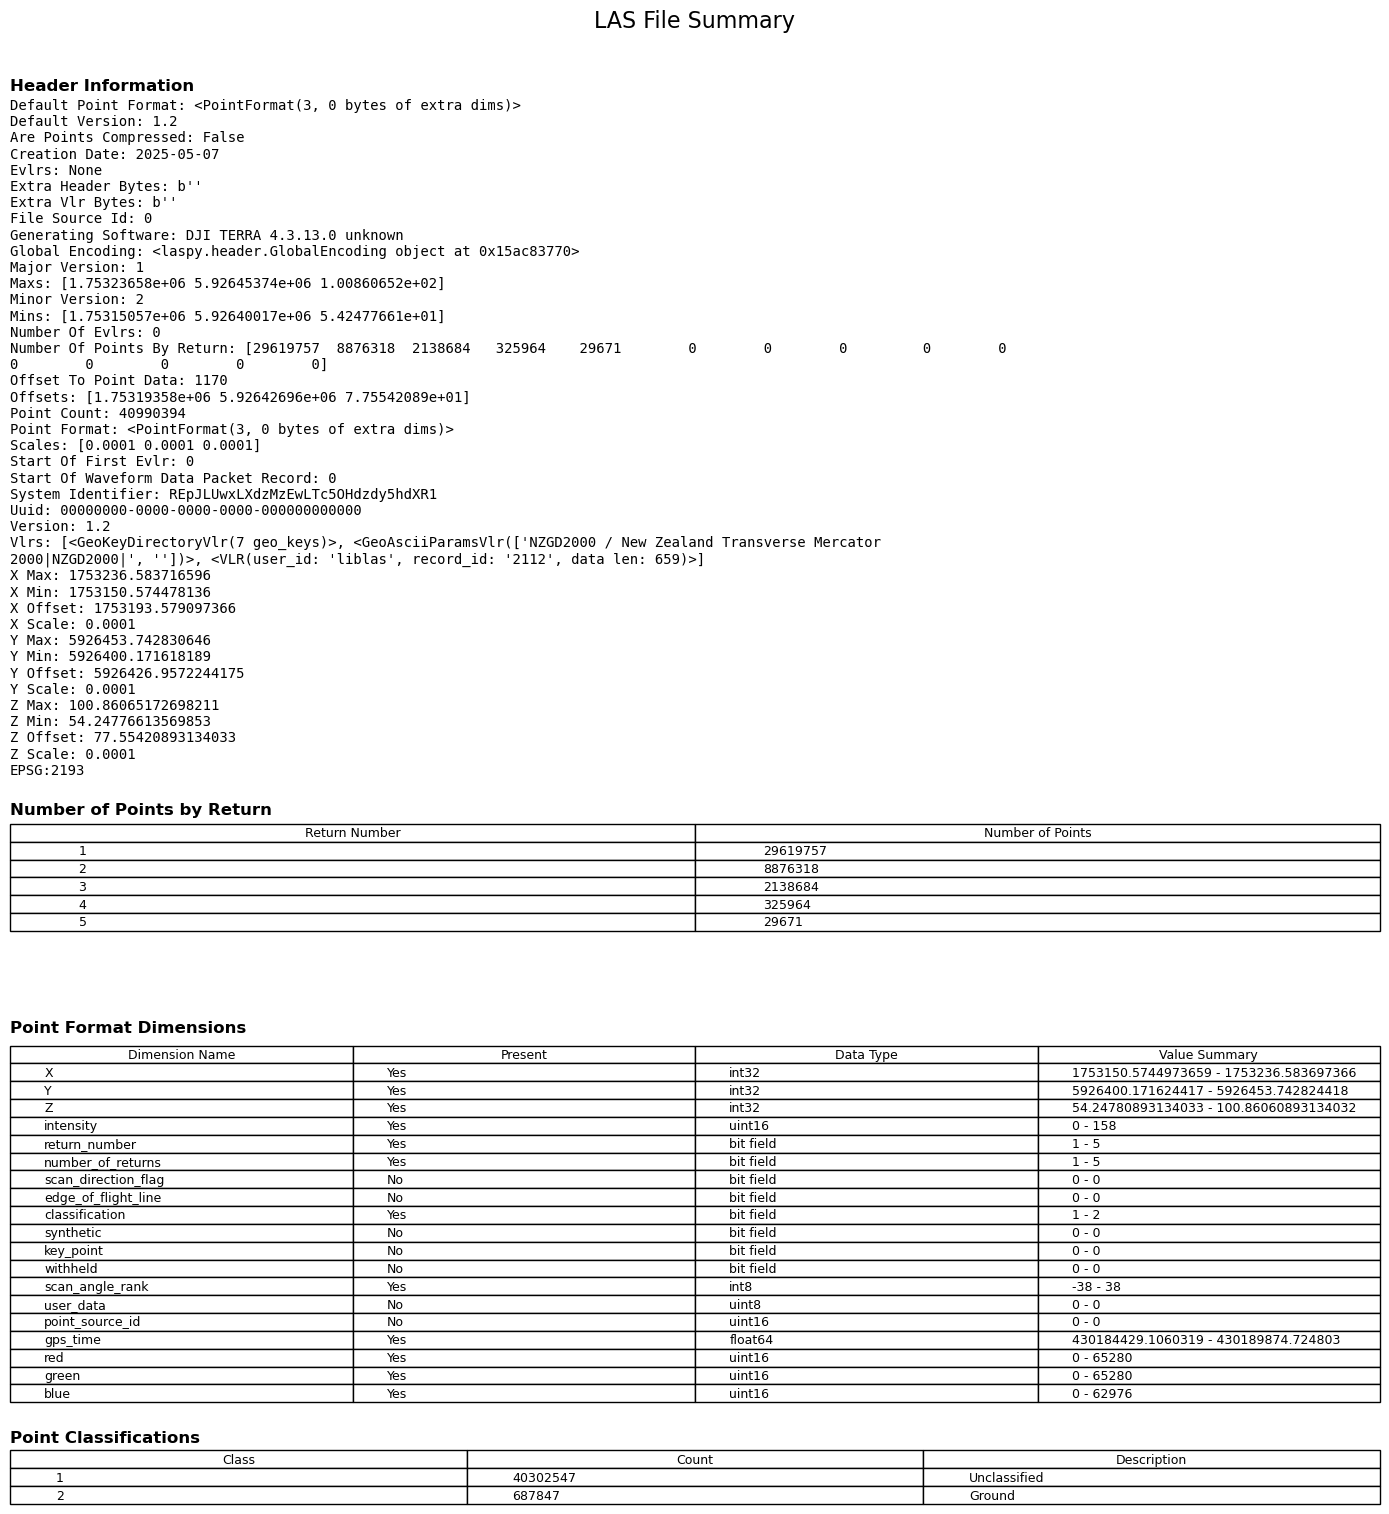


Point Density: 8896.22 points/m²
Total points: 40,990,394
Area: 4,608 m²


In [12]:
reserves = ['ESK']

for r in use(reserves):
    las = LAS(os.path.join(r.FE_R_LAS, 'Block_15.las'))
    #las = LAS(fr'D:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\TreeLearn\data\pipeline\L1W\forest\L1W.laz')
    las.info
    
    # Calculate point density
    import numpy as np
    num_points = len(las.points)
    min_x, max_x = las.header.mins[0], las.header.maxs[0]
    min_y, max_y = las.header.mins[1], las.header.maxs[1]
    area_m2 = (max_x - min_x) * (max_y - min_y)
    density = num_points / area_m2
    print(f"\nPoint Density: {density:.2f} points/m²")
    print(f"Total points: {num_points:,}")
    print(f"Area: {area_m2:,.0f} m²")

## Generate DTM and DSM 

In [ ]:
for site_r_las, site_p_dtm, site_p_dsm in zip(R_LAS, P_DTM, P_DSM):
    for las_file in list_files(site_r_las, '.las'):
        las = LAS(las_file)
        las.to_dem(site_p_dtm, 'DTM', resolution=0.1, fill_gaps= 15)
        las.to_dem(site_p_dsm, 'DSM', resolution=0.1, fill_gaps= 7)


### Merge generated DTM and DSM files

In [ ]:
from raster.utils import merge_raster

res_folder = 'res_010'

for site_p_dtm, site_p_dsm in zip(P_DTM, P_DSM):
    site_p_dtm_res = os.path.join(site_p_dtm, res_folder)
    site_p_dsm_res = os.path.join(site_p_dsm, res_folder)

    dtm_files_to_merge = list_files(site_p_dtm_res, '.tif')
    dsm_files_to_merge = list_files(site_p_dsm_res, '.tif')

    # Merge DTM
    if dtm_files_to_merge:
        dtm_output_path = os.path.join(site_p_dtm, f"{res_folder}.tif")
        merge_raster(dtm_files_to_merge, dtm_output_path)

    # Merge DSM
    if dsm_files_to_merge:
        dsm_output_path = os.path.join(site_p_dsm, f"{res_folder}.tif")
        merge_raster(dsm_files_to_merge, dsm_output_path)



Directory does not exist: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data/full_extent/C_kendal_bay/B_processed/DTM\res_010
Directory does not exist: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data/full_extent/C_kendal_bay/B_processed/DSM\res_010
Directory does not exist: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data/full_extent/D_bushglen/B_processed/DTM\res_010
Directory does not exist: d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data/full_extent/D_bushglen/B_processed/DSM\res_010


## Normalize las files to ground level

In [ ]:
# import libraries
import os
from config.paths import *
from utils.helper_functions import list_files
from lidar.las import LAS


for site_r_las, site_p_las, site_p_dtm in zip (R_LAS, P_LAS, P_DTM):
    r_las_list = list_files(site_r_las, '.las')

    if r_las_list:
        raster = os.path.join(site_p_dtm, 'res_010.tif')
        out_dir = os.path.join(site_p_las, 'ground_norm')
        os.makedirs(out_dir, exist_ok=True)

        for las_file in r_las_list:
            las = LAS(las_file)
            las_normalized = las.subtract_raster(raster)
            las_normalized.to_file(out_dir)

In [ ]:
display_las_extent(list_files(ESK_R_LAS, '.las'))

In [2]:
import laspy
import geopandas as gpd
from shapely.geometry import box
import numpy as np
from shapely import union_all
from pathlib import Path

def clip_las_to_polygon(las_path, boundary_gdf, output_path):
    """
    Clips a LAS file to the exact shape of a polygon from a GeoDataFrame.

    Args:
        las_path (str or Path): Path to the input LAS file.
        boundary_gdf (GeoDataFrame): GeoDataFrame containing the clipping polygon(s).
        output_path (str or Path): Path to save the clipped LAS file or a directory to save it in.

    Returns:
        None
    """
    las_path = Path(las_path)
    output_path = Path(output_path)
    if output_path.is_dir():
        output_path = output_path / las_path.name

    # Use union_all for faster geometry merge
    boundary_geom = union_all(boundary_gdf.geometry.values)

    with laspy.open(las_path) as las_file:
        las_bbox = box(*las_file.header.mins[:2], *las_file.header.maxs[:2])
        if not boundary_geom.intersects(las_bbox):
            print('No intersecting points 1.')
            return

        las = las_file.read()
        x, y = las.x, las.y

        # Fast bbox prefilter
        minx, miny, maxx, maxy = boundary_geom.bounds
        bbox_mask = (x >= minx) & (x <= maxx) & (y >= miny) & (y <= maxy)
        if not np.any(bbox_mask):
            print('No intersecting points 2.')
            return

        # Only test spatial containment on bbox-filtered points
        x_sub, y_sub = x[bbox_mask], y[bbox_mask]
        points = gpd.GeoSeries.from_xy(x_sub, y_sub, crs=boundary_gdf.crs)
        spatial_mask = points.within(boundary_geom)

        if not spatial_mask.any():
            print('No intersecting points 3.')
            return

        selected_indices = np.where(bbox_mask)[0][spatial_mask.values]
        new_las = laspy.LasData(las.header)
        new_las.points = las.points[selected_indices]

        new_las.write(output_path, do_compress=True)


In [4]:
from config.paths import use
from utils.helper_functions import list_files
import geopandas as gpd

reserves = ['KAU', 'ESK']

for r in use(reserves):
    las_files = list_files(r.FE_R_LAS, '.las')
    out= r.R_LAS
    gdf = gpd.read_file(os.path.join(r.GIS, 'bbox.gpkg'), layer = 'bbox')
    for las in las_files:

        clip_las_to_polygon(las, gdf, out)


Processing Reserves:   0%|          | 0/2 [00:00<?, ?it/s]

No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.


Processing Reserves:  50%|█████     | 1/2 [03:50<03:50, 230.56s/it]

No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.


Processing Reserves: 100%|██████████| 2/2 [12:03<00:00, 361.95s/it]

No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.
No intersecting points 1.


# Treesegmentation

## TreeIso

In [2]:
las = LAS(list_files(os.path.join(ESK_P_LAS, 'treeiso'),'.las')[0])
las.filter_by_dim('final_segs', os.path.join(ESK_P_LAS, 'treeiso_50000'), 50000)

## TreeLearn

In [2]:
las = LAS(list_files(os.path.join(ESK_P_LAS, 'treelearn'),'.las')[0])
las.filter_by_dim('treeID', os.path.join(ESK_P_LAS, 'treelearn_50000'), 50000)

In [4]:
las.dims

x
y
z
intensity
return_number
number_of_returns
scan_direction_flag
edge_of_flight_line
classification
synthetic
key_point
withheld
scan_angle_rank
user_data
point_source_id
red
green
blue
treeid
